# 양자 위협 강의 노트북
## Quantum Threats to Cryptography — Shor, Grover, HNDL

---

이 노트북은 **"왜 지금 양자내성암호(PQC, 양자컴퓨터로도 풀기 어렵게 만든 새 암호)인가"** 를
처음 배우는 분을 위한 강의 자료입니다. 수학을 전공하지 않아도 따라올 수 있도록,
어려운 수식 대신 일상 비유로 설명합니다.

오늘날의 암호를 위협하는 세 가지를 차례로 살펴봅니다.

- **Shor 알고리즘** — 인터넷에서 쓰는 자물쇠(공개키 암호)를 통째로 부수는 양자 알고리즘
- **Grover 알고리즘** — 금고 비밀번호(대칭키 암호)를 찾아내는 속도를 크게 올리는 양자 알고리즘
- **HNDL 공격** — "지금 훔쳐 두고, 양자컴퓨터가 나오면 그때 푼다"는 전략

각 주제를 쉬운 설명 → 작은 실험(시뮬레이션) → 결과 확인 → 그림 → 실무에서 무엇을 해야 하는가
순서로 직접 확인합니다.

> **안내**: 이 노트북은 통합본 `양자내성암호_입문자용_v3.ipynb`에서 해당 주제(양자 위협)를
> 분리·정리한 강의 자료입니다. 코드 셀과 출력은 원본 그대로이며,
> 재실행하려면 **0장(Setup) 셀을 먼저 실행**해야 합니다.

### 학습 목표
1. Shor 알고리즘이 왜 오늘날 인터넷 자물쇠(RSA·ECC)를 무너뜨리는지, 그 핵심 아이디어
   ("반복되는 주기를 찾으면 자물쇠가 열린다")를 이해합니다.
2. 그 원리를 작은 숫자로 컴퓨터에서 직접 재현해 봅니다.
3. Grover 알고리즘이 비밀번호 찾기를 얼마나 빠르게 하는지 숫자로 확인하고,
   왜 "열쇠를 2배로 길게" 하면 충분한 대응인지 이해합니다.
4. HNDL 공격의 구조와 모스카 부등식으로 "왜 지금 당장 갈아타야 하는가"를 판단합니다.
5. 위협별 실무 대응 우선순위(무엇을 먼저 바꿔야 하는가)를 도출합니다.

> **선행 지식**: 특별한 수학 지식 없이 읽을 수 있습니다. 곱하기·나누기 정도면 충분하며,
> 코드가 낯설어도 출력과 그림만 따라 읽으면 내용을 이해할 수 있습니다.
> 더 깊은 배경이 궁금하면 통합본 `양자내성암호_입문자용_v3.ipynb`를 참고하십시오.

## 0. 준비 (Setup)

실습은 `numpy`, `pandas`, `matplotlib` 라는 파이썬의 기본 계산·표·그림 도구만 사용합니다.
아래 공통 설정 셀(Harness)은 이 노트북 전체가 함께 쓰는 준비물을 만들어 둡니다.

- 실행할 때마다 결과가 똑같이 나오도록 난수(무작위 수)의 시작점을 고정합니다.
- 그래프의 한글이 깨지지 않도록 한글 폰트를 자동으로 찾아 설정합니다.
- 해시(데이터의 지문을 만드는 함수)·크기·시간을 재는 작은 도우미 함수들을 정의합니다.
- 결과 수치를 모아 두는 `METRICS` 저장소를 만듭니다.

이 노트북의 모든 코드 셀은 이 셀이 먼저 실행되었다는 전제에서 동작합니다.

In [1]:
import time, hashlib, secrets, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gcd, log2, floor, pi, sqrt

RNG = np.random.default_rng(20260722)   # 재현성 시드
plt.rcParams['figure.dpi'] = 110

# --- 한글 폰트 자동 설정 (그래프의 한글이 □□□로 깨지지 않게) ---
import matplotlib.font_manager as fm

def set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'Noto Sans CJK KR', 'Noto Sans KR', 'NanumBarunGothic']
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
            return name
    # 못 찾으면 리눅스/Colab에서 나눔폰트 설치 시도
    try:
        import subprocess, sys
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                       capture_output=True)
        for path in fm.findSystemFonts():
            if 'Nanum' in path:
                fm.fontManager.addfont(path)
        for name in candidates:
            if name in {f.name for f in fm.fontManager.ttflist}:
                plt.rcParams['font.family'] = name
                plt.rcParams['axes.unicode_minus'] = False
                return name
    except Exception:
        pass
    plt.rcParams['axes.unicode_minus'] = False
    print('⚠️ 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있어요. '
          'NanumGothic 등 한글 폰트를 설치한 뒤 다시 실행하세요.')
    return None

_font = set_korean_font()

# --- 해시 헬퍼 (해시 기반 서명·KEM 공유비밀에 사용) ---
def H(b: bytes) -> bytes:
    return hashlib.sha256(b).digest()
def shake(b: bytes, n: int) -> bytes:
    return hashlib.shake_128(b).digest(n)

# --- 크기 측정: 객체를 바이트로 직렬화해 대략적 전송량(byte)을 잰다 ---
def nbytes(obj) -> int:
    if isinstance(obj, (bytes, bytearray)):
        return len(obj)
    if isinstance(obj, np.ndarray):
        return obj.astype(np.int64).nbytes
    if isinstance(obj, (list, tuple)):
        return sum(nbytes(x) for x in obj)
    if isinstance(obj, str):
        return len(obj.encode())
    if isinstance(obj, int):
        return (obj.bit_length() + 7) // 8
    return sys.getsizeof(obj)

# --- 시간 측정 ---
def timeit(fn, *a, repeat=1, **k):
    t0 = time.perf_counter()
    for _ in range(repeat):
        out = fn(*a, **k)
    dt = (time.perf_counter() - t0) / repeat
    return out, dt

# --- 정량 지표 저장소 (Part IV 종합 비교에서 사용) ---
METRICS = {}
def log_metric(name, **kv):
    METRICS.setdefault(name, {}).update(kv)

print('Harness 준비 완료 · Python', sys.version.split()[0], '· NumPy', np.__version__,
      '· 한글 폰트:', _font)

Harness 준비 완료 · Python 3.13.14 · NumPy 2.4.6 · 한글 폰트: Malgun Gothic


## 1. Shor 알고리즘 — RSA·ECC 붕괴

### 1-1. 이론: 곱하기는 쉽지만 되돌리기는 어렵다

두 수를 곱하는 것은 쉽습니다. 5 × 7 = 35는 암산으로도 됩니다. 그런데 거꾸로
"35는 어떤 두 수의 곱인가?"를 맞히려면 이것저것 나눠 보는 수밖에 없습니다.
숫자가 수백 자리로 커지면 이 "거꾸로 문제"(소인수분해)는 세계 최고의 슈퍼컴퓨터로도
사실상 풀 수 없습니다.

인터넷에서 가장 널리 쓰이는 자물쇠인 **RSA**는 바로 이 사실 하나에 기대고 있습니다.
자물쇠(공개키)는 큰 곱셈 결과 N이고, 열쇠(개인키)는 그 N을 만든 두 소수 p, q입니다.
"곱한 결과는 공개해도, 어떤 두 수를 곱했는지는 아무도 못 맞힌다"가 RSA의 안전장치입니다.

그런데 1994년 Shor(쇼어)는 이 문제를 전혀 다른 문제로 바꾸는 방법을 발견했습니다.
아무 수 a를 골라 a, a×a, a×a×a, ... 를 계속 만들면서 매번 N으로 나눈 나머지만 적어 보면,
그 나머지들이 **일정한 간격으로 똑같이 반복**됩니다 — 시계 바늘이 12시간마다 제자리로
돌아오는 것과 같습니다. 이 반복 간격을 **주기(order)** 라고 부릅니다.

수식은 딱 하나만 기억하면 됩니다.

$$ a^r \equiv 1 \pmod{N} $$

> **수식 풀이:** a를 r번 거듭 곱한 뒤 N으로 나눈 나머지가 1로 돌아온다는 뜻입니다.
> 그런 일이 처음 일어나는 곱셈 횟수 r이 바로 "주기"입니다.
> ≡ 와 mod 는 "N으로 나눈 나머지가 같다"를 나타내는 기호일 뿐입니다.

놀라운 점은, 이 주기 r만 알아내면 나머지는 최대공약수 계산(두 수에 공통으로 들어 있는
가장 큰 약수 찾기 — 초등 수학 수준)만으로 p와 q가 높은 확률로 튀어나온다는 것입니다.

> **핵심**: 양자컴퓨터가 잘하는 일이 바로 이 "주기 찾기"입니다. 고전 컴퓨터로는 천문학적으로
> 오래 걸리는 주기 찾기를 양자컴퓨터(양자 위상추정, QPE)는 현실적인 시간 안에 해내고,
> 그 순간 RSA 자물쇠는 열립니다.

### 1-2. 실험 설계

충분한 성능의 양자컴퓨터는 아직 없으므로, 양자컴퓨터가 맡을 "주기 찾기" 단계만
보통 컴퓨터로 흉내 내고, 그 뒤의 최대공약수 계산은 그대로 둡니다.
작은 반소수(소수 두 개를 곱해 만든 수) 7개 — N = 15부터 899까지 — 를 실제로
소인수분해하여 "원리가 정말 성립하는지" 표로 확인합니다.

아래 셀은 주기 찾기 함수 `find_period` 와 Shor 후처리 `shor_factor` 를 구현합니다.
주기가 홀수이거나 조건이 맞지 않는 경우는 실패로 보고 다른 a로 다시 시도합니다.

In [2]:
# ③ 밑바닥 구현 — 주기 찾기(고전 대역) + Shor 후처리
def find_period(a, N):
    """a^r mod N = 1 이 되는 최소 r. (양자컴퓨터가 QPE로 지수적으로 가속하는 부분)"""
    x, r = a % N, 1
    while x != 1:
        x = (x * a) % N
        r += 1
        if r > N:
            return None
    return r

def shor_factor(N, rng):
    if N % 2 == 0:
        return 2, N // 2
    for _ in range(60):
        a = int(rng.integers(2, N - 1))
        g = gcd(a, N)
        if g > 1:                      # 운좋게 약수를 바로 뽑음
            return g, N // g
        r = find_period(a, N)
        if r is None or r % 2 == 1:    # 주기가 홀수면 실패 → 재시도
            continue
        y = pow(a, r // 2, N)
        if y == N - 1:                 # a^(r/2) ≡ -1 → 실패 → 재시도
            continue
        p = gcd(y - 1, N)
        if 1 < p < N:
            return p, N // p
    return None

# ④ 검증 — 여러 반소수를 인수분해
rows = []
for N in [15, 21, 35, 77, 143, 323, 899]:
    (p, q), dt = timeit(shor_factor, N, RNG)
    rows.append({'N': N, 'p': p, 'q': q, 'p*q==N': p*q == N, 'time_ms': dt*1e3})
df_shor = pd.DataFrame(rows)
print(df_shor.to_string(index=False))
print('\n→ 모든 반소수가 소인수로 분해됨. 양자컴이 주기찾기를 다항시간에 하면 RSA는 그대로 무너진다.')

  N  p  q  p*q==N  time_ms
 15  3  5    True   0.0964
 21  3  7    True   0.0161
 35  5  7    True   0.0121
 77  7 11    True   0.0097
143 11 13    True   0.0095
323 19 17    True   0.0273
899 31 29    True   0.0624

→ 모든 반소수가 소인수로 분해됨. 양자컴이 주기찾기를 다항시간에 하면 RSA는 그대로 무너진다.


### 1-3. 결과 해석

출력 표를 보면 N = 15, 21, 35, 77, 143, 323, 899 **일곱 개 모두 `p*q==N`이 `True`** 입니다.
즉 전부 올바른 두 소수로 쪼개졌습니다(예: 323 = 19 × 17, 899 = 31 × 29).
걸린 시간도 전부 0.1ms(1만분의 1초) 이하입니다 — 물론 이 속도는 숫자가 작아서이고,
우리가 흉내 낸 `find_period` 는 보통 컴퓨터 방식이라 숫자가 커지면 감당할 수 없이 느려집니다.

> **요점은 속도가 아니라 구조입니다.** "주기 찾기"라는 단 하나의 단계만 빨라지면
> RSA 전체가 무너지는 구조이고, 양자컴퓨터가 정확히 그 단계를 빠르게 해냅니다.

### 1-4. 시각화 — 반복되는 주기가 자물쇠를 여는 열쇠

N = 21, a = 2로 정하고, 2를 거듭 곱하면서 21로 나눈 나머지를 그림으로 그려 봅니다.
값이 일정한 간격으로 똑같이 반복되는 모습을 눈으로 확인하고, 그 주기를 이용해
실제로 21의 소인수를 복원합니다.

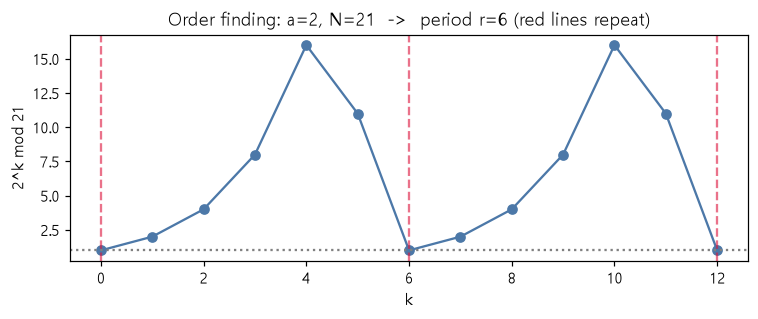

r=6, a^(r/2) mod N = 8, gcd(y-1,N)=7, gcd(y+1,N)=3  ->  21 = 3 x 7


In [3]:
N, a = 21, 2
ks = np.arange(0, 13)
vals = [pow(a, int(k), N) for k in ks]
r = find_period(a, N)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(ks, vals, 'o-', color='#4C78A8')
ax.axhline(1, color='gray', ls=':')
for m in range(0, 13, r):
    ax.axvline(m, color='crimson', ls='--', alpha=.6)
ax.set_title(f'Order finding: a={a}, N={N}  ->  period r={r} (red lines repeat)')
ax.set_xlabel('k'); ax.set_ylabel(f'{a}^k mod {N}')
plt.tight_layout(); plt.show()

# 이 주기로 실제 소인수 복원
y = pow(a, r//2, N)
print(f'r={r}, a^(r/2) mod N = {y}, gcd(y-1,N)={gcd(y-1,N)}, gcd(y+1,N)={gcd(y+1,N)}  ->  21 = 3 x 7')
log_metric('Shor(threat)', broken='RSA/ECC 완전붕괴', note='정수분해→주기찾기')

가로축은 곱한 횟수 k, 세로축은 "2를 k번 곱한 뒤 21로 나눈 나머지"입니다.
빨간 세로 점선은 같은 패턴이 다시 시작되는 지점인데, **정확히 6칸마다** 그어져 있습니다 —
나머지 값들이 주기 6으로 반복된다는 뜻입니다.

셀 출력에서 이 주기를 써먹은 결과를 볼 수 있습니다. 2를 3번(주기의 절반) 곱하면 8이고,
여기서 1을 뺀 7과 21의 최대공약수는 7, 1을 더한 9와 21의 최대공약수는 3입니다.
즉 최대공약수 계산만으로 **21 = 3 × 7** 이 복원되었습니다.

> RSA의 비밀은 이 "반복 주기"에 숨어 있습니다. 주기만 찾으면 나머지는 쉬운 계산뿐이며,
> 양자컴퓨터가 위협적인 이유는 바로 그 주기 찾기를 빠르게 해내기 때문입니다.

### 1-5. 실무 적용성

- **측정**: 작은 반소수들이 모두 소인수로 분해되었습니다. 핵심 단계는 주기 찾기이며, 실제 양자컴퓨터는 이것을 현실적인 시간 안에 해냅니다.
- **의미**: RSA뿐 아니라 Diffie-Hellman(공개된 통로로 둘만의 비밀 열쇠를 만드는 방식), ECC(타원곡선 암호 — 더 짧은 열쇠로 같은 안전성을 내는 방식) 등 **오늘날의 모든 공개키 암호가 안전하지 않게 됩니다.** 웹사이트 접속(TLS), 소프트웨어 서명, 전자여권까지 영향 범위가 매우 넓습니다.
- **수확 후 복호(Harvest Now, Decrypt Later)**: 공격자는 지금 암호문을 저장해 두었다가 훗날 양자컴퓨터로 풀 수 있으므로, **양자컴퓨터가 등장하기 전에 미리** 갈아타야 합니다(3장에서 숫자로 따져 봅니다).
- **해법**: 소인수분해나 이산로그(거듭제곱을 거꾸로 푸는 문제)가 아닌 **다른 어려운 문제**(격자·해시·코드·다변수)로 옮겨야 하며, 통합본의 Part II·III에서 이를 직접 구현합니다.

> **정리**: Shor 알고리즘 앞에서 지금의 공개키 암호(RSA·ECC)는 통째로 무너지므로,
> 문제 자체를 바꾼 새로운 암호(PQC)가 필요합니다. 교체 대상 1순위는 RSA·ECC 기반 인증서와 키교환입니다.

## 2. Grover 알고리즘 — 대칭키 약화

### 2-1. 이론: 건초더미에서 바늘 찾기가 빨라진다

AES 같은 **대칭키 암호**(잠글 때와 열 때 같은 열쇠를 쓰는 금고 방식)는 구조가 튼튼해서,
공격자가 할 수 있는 일은 사실상 "가능한 열쇠를 하나씩 다 넣어 보기"(완전탐색)뿐입니다.
열쇠가 b비트라면 가능한 열쇠는 2를 b번 곱한 개수만큼 있고, 평균적으로 그 절반을 시도해야
합니다. 128비트 열쇠라면 우주의 나이보다 오래 걸리는 양입니다.

1996년 Grover(그로버)는 양자컴퓨터로 이 "다 넣어 보기"를 **제곱근만큼** 줄이는 방법을
찾았습니다. 예컨대 1조 번 시도할 일을 약 100만 번(1조의 제곱근)으로 줄이는 식입니다.
건초더미에서 바늘 찾기를 "제곱근 배" 빨리 해 주는 셈입니다.

> **핵심**: 시도 횟수의 지수가 b에서 b/2로 줄어듭니다. 즉 **열쇠의 유효 강도(비트 수)가
> 절반**이 됩니다. 128비트 열쇠가 64비트짜리처럼 약해지는 것입니다.

### 2-2. 실험 설계

Shor가 공개키 자물쇠를 **완전히 부수는** 것과 달리, Grover는 열쇠 구멍이 절반 크기로
줄어드는 정도입니다. 자물쇠 자체는 멀쩡하므로, **열쇠를 2배로 길게** 만들면 원래 강도로
돌아옵니다. 이것을 숫자로 확인합니다.

아래 셀은 열쇠 길이 64, 80, 128, 192, 256비트에 대해 보통 컴퓨터의 완전탐색 비용과
Grover 적용 시 비용, 그리고 유효 강도(실질적으로 몇 비트짜리 열쇠인가)를 표로 계산합니다.
숫자가 너무 커서 그대로 다룰 수 없으므로 "2를 몇 번 곱한 크기인가"(log2 스케일)로 표시합니다.

In [4]:
# ③④ 대칭키 유효 강도 계산 (log2 스케일로 오버플로 방지)
def grover_log2_iters(b):
    return b/2 + log2(pi/4)          # log2(Grover 반복 수) ~ b/2

rows = []
for b in [64, 80, 128, 192, 256]:
    rows.append({'key_bits': b,
                 'classical_log2': b - 1,
                 'grover_log2': round(grover_log2_iters(b), 1),
                 'effective_bits': b // 2})
df_grv = pd.DataFrame(rows)
print(df_grv.to_string(index=False))
print('\n→ AES-128은 Grover 하에서 유효 64비트 → 불안. AES-256은 유효 128비트 → 안전.')
log_metric('Grover(threat)', broken='대칭키 강도 절반', fix='키 길이 2배(AES-256)')

 key_bits  classical_log2  grover_log2  effective_bits
       64              63         31.7              32
       80              79         39.7              40
      128             127         63.7              64
      192             191         95.7              96
      256             255        127.7             128

→ AES-128은 Grover 하에서 유효 64비트 → 불안. AES-256은 유효 128비트 → 안전.


### 2-3. 결과 해석

출력 표에서 보통 컴퓨터의 공격 비용(`classical_log2`)은 열쇠 길이를 거의 그대로 따라가지만
(128비트 → 127), Grover 비용(`grover_log2`)은 정확히 그 절반 수준입니다(128비트 → 63.7).

- **AES-128**: 유효 64비트 — 통용되는 안전 기준(128비트)에 못 미쳐 **불안**합니다.
- **AES-256**: 유효 128비트 — 안전 기준을 충족합니다.

### 2-4. 시각화 — 고전 vs Grover 공격 비용

열쇠 길이별로 보통 컴퓨터의 완전탐색 비용과 Grover 적용 시 비용을 나란히 그려,
강도가 정확히 절반으로 줄어드는 모습과 128비트 안전선을 함께 확인합니다.

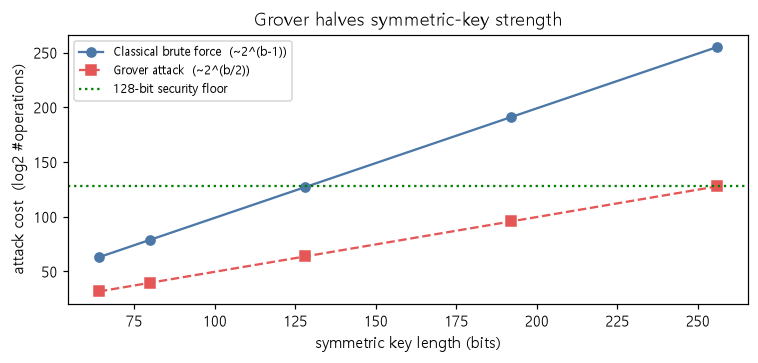

In [5]:
bs = df_grv['key_bits'].values
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(bs, df_grv['classical_log2'], 'o-', label='Classical brute force  (~2^(b-1))', color='#4C78A8')
ax.plot(bs, df_grv['grover_log2'],   's--', label='Grover attack  (~2^(b/2))',      color='#E45756')
ax.axhline(128, color='green', ls=':', label='128-bit security floor')
ax.set_xlabel('symmetric key length (bits)'); ax.set_ylabel('attack cost  (log2 #operations)')
ax.set_title('Grover halves symmetric-key strength'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

가로축은 대칭키 길이(비트), 세로축은 공격에 필요한 연산량("2를 몇 번 곱한 크기인가",
log2 스케일)입니다. 파란 실선(보통 컴퓨터의 완전탐색)은 열쇠 길이를 거의 그대로 따라
올라가지만, 빨간 점선(Grover)은 **정확히 그 절반 기울기**입니다. 초록 가로 점선이
128비트 안전선입니다.

- AES-128은 Grover 하에서 유효 64비트가 되어 안전선 **아래**로 떨어집니다(위험).
- AES-256은 유효 128비트로 안전선에 **도달**합니다(안전).

> 열쇠 구멍이 절반으로 줄어드는 것일 뿐이므로, 열쇠를 2배로 길게 만들면 원상복구됩니다.

### 2-5. 실무 적용성

- **측정**: Grover는 대칭키 강도를 정확히 절반으로 줄입니다. AES-128은 유효 64비트(위험), **AES-256은 유효 128비트(안전)** 입니다.
- **대응이 쉽습니다**: 공개키와 달리 대칭키는 **열쇠 길이만 2배**로 늘리면 되므로 새 알고리즘이 필요 없습니다. 해시(데이터의 지문을 만드는 함수)도 마찬가지로 출력을 키우면 됩니다(SHA-256 → SHA-384/512 권장).
- **결론**: 진짜 문제는 **공개키**입니다. 미국 표준기관 NIST의 PQC 표준화가 공개키 암호 — KEM(둘이 같은 비밀 열쇠를 나눠 갖는 절차)과 서명(내용이 진짜임을 보증하는 도장) — 에 집중되는 이유이며, 통합본 Part II가 그 해법(4대 유형), Part III·IV가 QKD와 전환 전략을 다룹니다.

> **정리**: Grover는 대칭키를 "절반만" 약화시키므로 AES-256과 SHA-384 이상으로 올리는 것으로
> 대비가 끝납니다 — 급한 불은 공개키 쪽입니다.

## 3. HNDL 공격과 모스카 부등식

### 3-1. 이론: 지금 훔쳐서 나중에 푼다

양자컴퓨터가 **아직 없어도** 위협은 이미 시작되었습니다.
**HNDL(Harvest Now, Decrypt Later — 지금 수확하고 나중에 복호하기)** 은 공격자가 지금 오가는
암호문을 **미리 수집·저장**해 두었다가, 훗날 암호를 실제로 깰 수 있는 수준의 양자컴퓨터
(**CRQC**, Cryptographically Relevant Quantum Computer)가 등장하면 **한꺼번에 풀어 버리는**
전략입니다. 지금은 못 여는 금고라도 통째로 훔쳐 창고에 쌓아 두면, 나중에 만능 열쇠가
생겼을 때 열 수 있는 것과 같습니다.

구조는 단순합니다: **오늘(수집) → 대기(저장) → 미래(복호)**.
따라서 "몇 년 뒤에도 비밀이어야 하는 데이터"(금융·의료·국방·외교)는 지금 이 순간에도 위험합니다.

### 3-2. 모스카 부등식 — "이미 늦었는가"를 계산하는 공식

이사에 비유하면 쉽습니다. 집을 비워 줘야 하는 날까지 남은 시간보다, 짐 싸는 데 걸리는
시간과 그 짐을 지켜야 하는 기간의 합이 더 길면 계획은 이미 파탄입니다. 변수는 세 가지입니다.

| 변수 | 의미 |
|---|---|
| S | 데이터 기밀 수명 — 이 데이터가 몇 년 동안 비밀이어야 하는가 |
| M | 마이그레이션 기간 — 새 암호(PQC)로 갈아타는 데 걸리는 시간 |
| T | CRQC 등장까지 남은 기간 |

$$ S + M > T $$

> **수식 풀이:** "비밀을 지켜야 하는 햇수(S)"와 "갈아타는 데 걸리는 햇수(M)"를 더한 값이
> "양자컴퓨터가 오기까지 남은 햇수(T)"보다 크면, 그 데이터는 언젠가 반드시 노출된다는
> 뜻입니다. 이것이 **모스카의 정리(Mosca's theorem)** 이며, 이 부등식이 성립하면
> **이미 늦은 것**입니다.

아래 셀은 네 가지 데이터 시나리오(장기 의료기록·금융 거래기록·국가기밀 문서·일반 웹세션)에
대해 현재 시점 2026년, CRQC 도래 2035년, 전환기간 M = 7년 가정으로 이 판정을 수행합니다.

In [6]:
# ③④ 모스카 부등식: 데이터 기밀수명 + 전환기간 vs 양자컴 도래시점
scenarios = [
    ('장기 의료기록', 25, 7, 2035),
    ('금융 거래기록', 10, 7, 2035),
    ('국가기밀 문서', 30, 7, 2035),
    ('일반 웹세션',    1, 7, 2035),
]
NOW = 2026
rows = []
for name, S, M, crqc in scenarios:
    T = crqc - NOW                 # 양자컴까지 남은 기간
    at_risk = (S + M) > T          # 모스카: 지금 시작해도 늦는가
    rows.append({'데이터': name, '기밀수명 S': S, '전환기간 M': M,
                 'CRQC까지 T': T, 'S+M': S+M, '이미_위험': at_risk})
df_hndl = pd.DataFrame(rows)
print(df_hndl.to_string(index=False))
print('\n→ S+M > T 인 데이터는 CRQC가 오기 전에 이미 노출 위험. 장기 기밀일수록 지금 전환해야 한다.')
log_metric('HNDL', rule='Mosca: S+M>T', note='장기기밀은 지금 전환')

    데이터  기밀수명 S  전환기간 M  CRQC까지 T  S+M  이미_위험
장기 의료기록      25       7         9   32   True
금융 거래기록      10       7         9   17   True
국가기밀 문서      30       7         9   37   True
 일반 웹세션       1       7         9    8  False

→ S+M > T 인 데이터는 CRQC가 오기 전에 이미 노출 위험. 장기 기밀일수록 지금 전환해야 한다.


### 3-3. 결과 해석

CRQC까지 남은 시간은 T = 2035 − 2026 = 9년입니다. 출력 표에서

- **장기 의료기록**: S+M = 25+7 = 32 > 9 → 이미 위험
- **금융 거래기록**: S+M = 10+7 = 17 > 9 → 이미 위험
- **국가기밀 문서**: S+M = 30+7 = 37 > 9 → 이미 위험
- **일반 웹세션**: S+M = 1+7 = 8 ≤ 9 → 아직 여유

기밀 수명이 짧은 웹세션을 제외한 모든 장기 기밀 데이터가 **지금 전환을 시작해도 늦는**
구간에 있습니다.

### 3-4. 시각화 — 모스카 타임라인

데이터 종류별로 S+M(지켜야 할 햇수 + 갈아타는 햇수)을 가로 막대로 그리고,
CRQC까지 남은 시간 T를 세로 점선으로 긋습니다. 막대가 점선을 넘으면(빨간색)
이미 위험 구간이라는 뜻입니다.

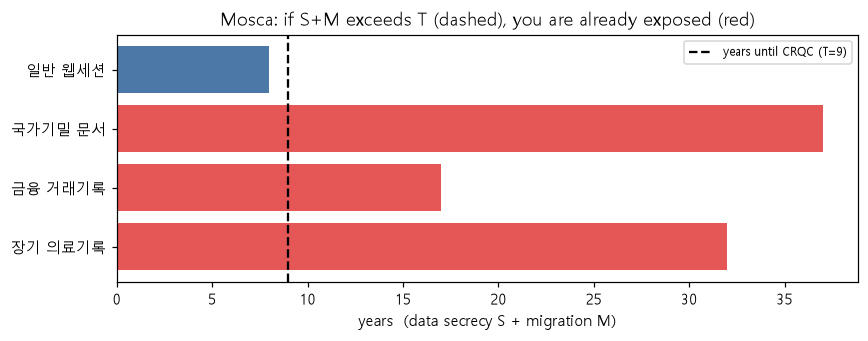

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.2))
names = [r['데이터'] for r in rows]
y = np.arange(len(names))
for i, r in enumerate(rows):
    ax.barh(i, r['S+M'], color='#E45756' if r['이미_위험'] else '#4C78A8')
T = 2035 - NOW
ax.axvline(T, color='black', ls='--', label=f'years until CRQC (T={T})')
ax.set_yticks(y); ax.set_yticklabels(names)
ax.set_xlabel('years  (data secrecy S + migration M)')
ax.set_title('Mosca: if S+M exceeds T (dashed), you are already exposed (red)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

막대 하나가 데이터 한 종류이며, 막대 길이는 기밀 수명 S와 전환기간 M = 7년의 합입니다.
검은 세로 점선이 CRQC까지 남은 시간 T = 9년입니다.

빨간 막대들 — 장기 의료기록(32년), 국가기밀 문서(37년), 금융 거래기록(17년) — 은 점선을
훌쩍 넘고, 점선 안쪽에 있는 것은 일반 웹세션(8년, 파란 막대)뿐입니다.

> 막대가 점선을 넘는다는 것은 "지금 이 순간 도청당한 암호문이, 아직 비밀이어야 할 때
> 풀려 버린다"는 뜻입니다. 이삿짐(전환 7년)을 싸는 동안에도 시계는 계속 가므로,
> "양자컴퓨터가 나오면 그때 바꾸자"는 계산상 이미 늦습니다.

### 3-5. 실무 적용성

- **측정**: 기밀 수명이 긴 데이터(의료·국가기밀)는 S+M이 T를 넘으므로, CRQC가 오기 전인 지금도 이미 노출 위험 구간에 있습니다.
- **함의**: "양자컴퓨터가 나오면 그때 바꾸자"는 늦습니다. 갈아타는 일 자체가 수년 걸리므로 **거꾸로 계산하여 지금 시작**해야 합니다.
- **우선순위**: 데이터의 **기밀 수명을 기준으로 전환 우선순위**를 매기십시오 — 오래 지켜야 하는 데이터일수록 전환 시작이 급합니다.
- **연결**: 통합본 Part II에서 **대체 암호(PQC 4대 유형)** 를 구현하고, Part IV에서 **전환 방법**(하이브리드·단계적 전환)을 다룹니다.

> **정리**: 오래 지켜야 할 비밀일수록 지금 당장 PQC 전환을 시작해야 하며,
> 모스카 부등식이 그 마감 시한을 알려 줍니다.

## 연습문제

직접 코드를 고쳐 보면서 감을 잡아 보십시오.

1. **더 큰 반소수**: 1장 검증 셀의 리스트 `[15, 21, 35, 77, 143, 323, 899]` 에
   1763(= 41 × 43), 3599(= 59 × 61) 등을 추가하고 걸린 시간(`time_ms`)이 어떻게 커지는지
   관찰하십시오. 보통 컴퓨터 방식의 주기 찾기(`find_period`)가 왜 큰 수에서 병목이 되는지,
   양자컴퓨터가 대신해 주는 단계가 정확히 어디인지 자신의 말로 설명해 보십시오.

2. **밑수 a 바꾸기**: 1-4 시각화 셀에서 `N, a = 21, 2` 의 a를 4, 5, 8 등으로 바꿔
   주기가 어떻게 달라지는지 확인하십시오. 주기가 홀수이거나 조건이 맞지 않아
   소인수 복원이 실패하는 a도 찾아보고, `shor_factor` 가 이런 경우를 어떻게
   (다른 a로 재시도) 처리하는지 코드에서 확인하십시오.

3. **중간 키 길이**: 2장 계산 셀의 리스트 `[64, 80, 128, 192, 256]` 에 96, 112비트를
   추가하여, 유효 강도(`effective_bits`)가 128비트 안전선을 넘는 최소 열쇠 길이가
   얼마인지 확인하십시오. AES-192의 유효 강도는 어디에 위치합니까?

4. **모스카 시나리오 실험**: 3장 셀에서 전환기간 M을 7년에서 5년/10년으로,
   CRQC 예상 시점을 2035년에서 2030년/2040년으로 바꿔 `이미_위험` 판정이 어떻게 변하는지
   관찰하십시오. 자신이 속한 조직의 대표 데이터를 `scenarios` 에 한 줄 추가해
   위험 여부를 판정해 보십시오.

## 요약

- **Shor 알고리즘**: "곱하기는 쉽지만 거꾸로 쪼개기는 어렵다"에 기대던 RSA를, "반복 주기만 찾으면 열린다"는 구조로 바꿔 버립니다. 양자컴퓨터는 그 주기 찾기를 빠르게 해내므로 **RSA·DH·ECC 등 공개키 암호가 완전히 무너집니다.**
- 시뮬레이션에서 주기만 알면 최대공약수 계산만으로 소인수가 복원됨을 확인했습니다(21 = 3 × 7 등 반소수 7개 전부 성공).
- **Grover 알고리즘**: 열쇠 완전탐색을 제곱근만큼 가속하여 대칭키 유효 강도를 절반으로 줄이지만, **열쇠 길이 2배(AES-256, SHA-384 이상)로 충분히 대응**할 수 있습니다.
- **HNDL 공격** 때문에 양자컴퓨터가 등장하기 전인 지금도 장기 기밀 데이터는 이미 위험합니다.
- **모스카 부등식 S + M > T** 가 전환 마감 시한을 숫자로 알려 줍니다 — 시나리오 분석에서 의료(32년)·국가기밀(37년)·금융(17년) 데이터는 T = 9년을 초과하여 이미 위험 구간이었습니다.
- 결론: 대칭키는 열쇠를 키우는 것으로 충분하지만 **공개키는 문제 자체를 바꾼 새 암호(PQC)로 교체**해야 하며, 기밀 수명이 긴 데이터부터 지금 전환을 시작해야 합니다.

> 이어지는 노트북들에서 격자·해시·코드·다변수 기반의 PQC 알고리즘(ML-KEM, ML-DSA, SLH-DSA 등
> 4대 유형)을 밑바닥부터 구현하며, 이 위협에 대한 해법을 하나씩 확인합니다.